In [2]:
import cv2
import numpy as np

# 영상 경로
video_path = "fan_spin.mp4"
cap = cv2.VideoCapture(video_path)

# ROI (팬 위치)
x, y, w, h = 245, 62, 245, 325

# Farneback 파라미터
pyr_scale = 0.5
levels = 3
winsize = 15
iterations = 3
poly_n = 5
poly_sigma = 1.2

prev_gray = None
hsv_mask = None

# 출력 영상 저장 옵션 (원하면 주석 해제)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('flow_visualized.mp4', fourcc, 10.0, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]

    if prev_gray is not None:
        roi_prev = prev_gray[y:y+h, x:x+w]

        # Optical Flow 계산
        flow = cv2.calcOpticalFlowFarneback(
            roi_prev, roi_gray, None,
            pyr_scale, levels, winsize, iterations, poly_n, poly_sigma, 0
        )

        # Flow → 극좌표 (크기, 각도)
        mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

        # HSV 시각화: 각도 → 색상(H), 크기 → 밝기(V)
        hsv_mask = np.zeros_like(cv2.cvtColor(roi_color, cv2.COLOR_BGR2HSV))
        hsv_mask[..., 1] = 255  # Saturation = 255
        hsv_mask[..., 0] = ang * 180 / np.pi / 2  # 방향 → 색상(H)
        hsv_mask[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)  # 속도 → 밝기(V)

        # HSV → BGR (시각화용 컬러 이미지)
        flow_bgr = cv2.cvtColor(hsv_mask, cv2.COLOR_HSV2BGR)

        # 컬러 맵 오버레이 (원본 ROI 위에 흐름 색상 덧입힘)
        overlay = cv2.addWeighted(roi_color, 0.6, flow_bgr, 0.8, 0)

        out.write(overlay)

    prev_gray = gray.copy()

cap.release()
out.release()


error: OpenCV(4.10.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [6]:
import cv2
import numpy as np

video_path = "fan_spin.mp4"
cap = cv2.VideoCapture(video_path)

x, y, w, h = 245, 62, 245, 325
prev_gray = None

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('flow_speed_only.mp4', fourcc, 30.0, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]

    if prev_gray is not None:
        roi_prev = prev_gray[y:y+h, x:x+w]
        flow = cv2.calcOpticalFlowFarneback(
            roi_prev, roi_gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )
        mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])

        # 속도 크기(mag)를 0~255 범위로 정규화
        mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
        mag_uint8 = mag_norm.astype(np.uint8)

        # 색상 맵 적용 (속도 크기 기반)
        # 옵션: COLORMAP_JET / HOT / INFERNO / TURBO
        flow_color = cv2.applyColorMap(mag_uint8, cv2.COLORMAP_TURBO)

        # 원본 ROI와 오버레이
        overlay = cv2.addWeighted(roi_color, 0.6, flow_color, 0.8, 0)
        out.write(overlay)

    prev_gray = gray.copy()

cap.release()
out.release()
print("✅ 속도 기반 Optical Flow 시각화 영상 저장 완료: flow_speed_only.mp4")


✅ 속도 기반 Optical Flow 시각화 영상 저장 완료: flow_speed_only.mp4


📹 FPS: 30.0
Frame 30: flow_mean = 2.8727
Frame 60: flow_mean = 0.7336
Frame 90: flow_mean = 1.0552
Frame 120: flow_mean = 1.0521
Frame 150: flow_mean = 0.7304
Frame 180: flow_mean = 0.8754
Frame 210: flow_mean = 0.5252
Frame 240: flow_mean = 0.8874
Frame 270: flow_mean = 0.9783
Frame 300: flow_mean = 0.6902
Frame 330: flow_mean = 0.7340
Frame 360: flow_mean = 0.4973
Frame 390: flow_mean = 0.7473
Frame 420: flow_mean = 1.0055
Frame 450: flow_mean = 1.5259
Frame 480: flow_mean = 1.7828
Frame 510: flow_mean = 2.1449
Frame 540: flow_mean = 2.0970
Frame 570: flow_mean = 1.5091
Frame 600: flow_mean = 2.1584
Frame 630: flow_mean = 1.1413
Frame 660: flow_mean = 0.6367
Frame 690: flow_mean = 1.4618
Frame 720: flow_mean = 1.3152
Frame 750: flow_mean = 1.4081
Frame 780: flow_mean = 1.7023
Frame 810: flow_mean = 2.1600
Frame 840: flow_mean = 2.0409
Frame 870: flow_mean = 2.4730
Frame 900: flow_mean = 1.9439
Frame 930: flow_mean = 2.1012
Frame 960: flow_mean = 2.4541
Frame 990: flow_mean = 2.2044
F

/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 54060 (\N{HANGUL SYLLABLE PAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3471586879.py:64: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu S

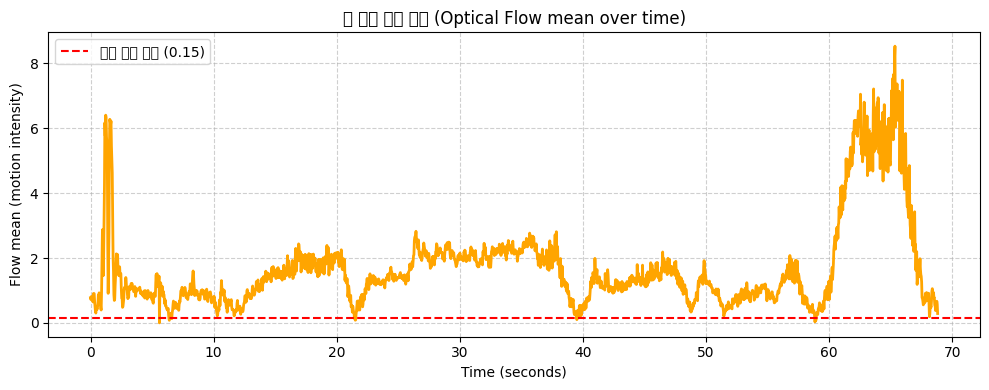

✅ flow_mean.csv / flow_mean_plot.png 저장 완료!


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

video_path = "fan_spin.mp4"
cap = cv2.VideoCapture(video_path)

# ROI 좌표
x, y, w, h = 245, 62, 245, 325
prev_gray = None
flow_means = []

frame_idx = 0
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or np.isnan(fps):
    fps = 30.0
print(f"📹 FPS: {fps}")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_gray = gray[y:y+h, x:x+w]

    if prev_gray is not None:
        roi_prev = prev_gray[y:y+h, x:x+w]
        flow = cv2.calcOpticalFlowFarneback(
            roi_prev, roi_gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        flow_mean = np.mean(mag)
        flow_means.append(flow_mean)

        if frame_idx % 30 == 0:
            print(f"Frame {frame_idx}: flow_mean = {flow_mean:.4f}")

    prev_gray = gray.copy()
    frame_idx += 1

cap.release()

# CSV 저장
with open("flow_mean.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame", "time_sec", "flow_mean"])
    for i, val in enumerate(flow_means):
        writer.writerow([i, i/fps, val])

# 그래프 시각화
time_axis = np.arange(len(flow_means)) / fps
plt.figure(figsize=(10, 4))
plt.plot(time_axis, flow_means, color='orange', linewidth=2)
plt.axhline(y=0.15, color='red', linestyle='--', label='정지 판단 기준 (0.15)')
plt.xlabel("Time (seconds)")
plt.ylabel("Flow mean (motion intensity)")
plt.title("팬 회전 강도 변화 (Optical Flow mean over time)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("flow_mean_plot.png", dpi=200)
plt.show()

print("✅ flow_mean.csv / flow_mean_plot.png 저장 완료!")


In [8]:
import cv2
import numpy as np

video_path = "fan_spin.mp4"
cap = cv2.VideoCapture(video_path)

x, y, w, h = 245, 62, 245, 325
prev_gray = None

# 저장 설정
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or np.isnan(fps):
    fps = 30
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('flow_direction_vectors.mp4', fourcc, fps, (w, h))

# 화살표 밀도 (간격)
step = 20  # 화살표 간격 (픽셀 단위)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w].copy()

    if prev_gray is not None:
        roi_prev = prev_gray[y:y+h, x:x+w]
        flow = cv2.calcOpticalFlowFarneback(
            roi_prev, roi_gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )
        u = flow[..., 0]
        v = flow[..., 1]
        mag, ang = cv2.cartToPolar(u, v)

        # 화살표 위치 샘플링
        h_roi, w_roi = roi_gray.shape
        y_grid, x_grid = np.mgrid[step/2:h_roi:step, step/2:w_roi:step].astype(int)

        for i in range(y_grid.shape[0]):
            for j in range(y_grid.shape[1]):
                px = x_grid[i, j]
                py = y_grid[i, j]

                # 해당 위치의 flow 벡터
                dx = int(u[py, px])
                dy = int(v[py, px])

                # 벡터 크기가 작으면 무시
                if np.sqrt(dx**2 + dy**2) < 1:
                    continue

                # 화살표 그리기
                cv2.arrowedLine(roi_color, (px, py), (px + dx*2, py + dy*2),
                                (0, 255, 0), 1, tipLength=0.4)

        out.write(roi_color)

    prev_gray = gray.copy()

cap.release()
out.release()
print("✅ 방향 벡터 시각화 영상 저장 완료: flow_direction_vectors.mp4")


✅ 방향 벡터 시각화 영상 저장 완료: flow_direction_vectors.mp4


In [11]:
import cv2, numpy as np

video_path = "fan_spin.mp4"
cap = cv2.VideoCapture(video_path)

# ROI (resize 후 기준)
x, y, w, h = 245, 62, 245, 325
fps = 30.0

# Farnebäck 튜닝
FB = dict(pyr_scale=0.5, levels=5, winsize=21, iterations=5, poly_n=7, poly_sigma=1.5, flags=0)

# 1) 전역 vmax 산출을 위한 1차 패스 (샘플링)
def estimate_vmax(path, sample_stride=5, max_samples=200):
    cap2 = cv2.VideoCapture(path)
    prev = None; vmax = 0.0; n=0
    while True:
        ret, f = cap2.read()
        if not ret: break
        if n % sample_stride == 0:
            fr = cv2.resize(f, (640,480)); g = cv2.cvtColor(fr, cv2.COLOR_BGR2GRAY)
            roi = g[y:y+h, x:x+w]
            if prev is not None:
                flow = cv2.calcOpticalFlowFarneback(prev, roi, None, **FB)
                mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
                vmax = max(vmax, np.percentile(mag, 99))  # 아웃라이어 억제
            prev = roi
        n += 1
        if n > max_samples: break
    cap2.release()
    return max(vmax, 1e-6)

vmax = estimate_vmax(video_path)  # 전역 상한 (예: 3.5~8.0 근방 나올 것)
print("Global vmax:", vmax)

# 2) 원판 마스크 (ROI 내부 원형)
mask = np.zeros((h, w), np.uint8)
cx, cy = w//2, h//2
radius = min(w,h)//2 - 6
cv2.circle(mask, (cx,cy), radius, 255, -1)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('flow_speed_only_global.mp4', fourcc, fps, (w, h))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
prev_gray = None
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.resize(frame, (640,480))
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_g = gray[y:y+h, x:x+w]
    roi_c = frame[y:y+h, x:x+w].copy()

    if prev_gray is not None:
        flow = cv2.calcOpticalFlowFarneback(prev_gray, roi_g, None, **FB)
        mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])

        # 마스크 적용 + 전역 스케일 고정
        mag_masked = np.where(mask==255, mag, 0.0)
        mag_clipped = np.clip(mag_masked, 0, vmax)
        mag_uint8 = (mag_clipped / vmax * 255.0).astype(np.uint8)

        flow_color = cv2.applyColorMap(mag_uint8, cv2.COLORMAP_TURBO)
        overlay = cv2.addWeighted(roi_c, 0.6, flow_color, 0.8, 0)
        out.write(overlay)

    prev_gray = roi_g

cap.release(); out.release()
print("✅ 저장: flow_speed_only_global.mp4")


Global vmax: 31.838684
✅ 저장: flow_speed_only_global.mp4


🎥 FPS: 30.0
✅ 저장 완료: rotation_phasecorr.mp4


/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3056289084.py:113: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu 

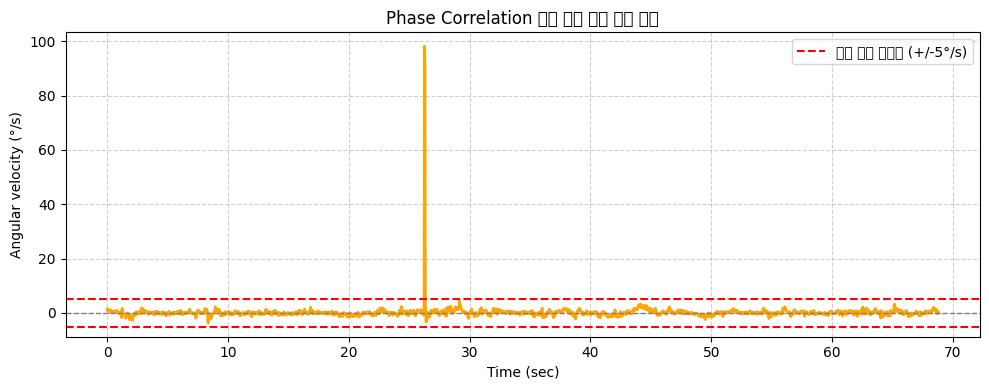

✅ rotation_speed.csv / rotation_speed_plot.png 생성 완료


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# ==== 설정 ====
video_path = "fan_spin.mp4"
x, y, w, h = 245, 62, 245, 325  # 팬 ROI
polar_w = 720     # polar 이미지의 각도 해상도 (360° 대응)
polar_h = int(min(w, h) / 2)  # 반지름

# ==== 영상 읽기 ====
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or np.isnan(fps):
    fps = 30.0
print(f"🎥 FPS: {fps}")

# ==== Phase Correlation 기반 각속도 추정 ====
def estimate_omega(prev_gray, curr_gray, mask, center, radius):
    # Polar 변환 (원 → 선형)
    flags = cv2.WARP_POLAR_LINEAR + cv2.WARP_FILL_OUTLIERS
    prev_p = cv2.warpPolar(prev_gray, (polar_w, polar_h), center, radius, flags)
    curr_p = cv2.warpPolar(curr_gray, (polar_w, polar_h), center, radius, flags)

    # 조명 변화 억제용 블러
    prev_p = cv2.GaussianBlur(prev_p, (5,5), 0)
    curr_p = cv2.GaussianBlur(curr_p, (5,5), 0)

    # 위상 상관으로 각도축 시프트 추정
    shift, _ = cv2.phaseCorrelate(np.float32(prev_p), np.float32(curr_p))
    dx = shift[0]  # polar x축 이동량

    # 이동량 → 각도 변화 (deg/frame)
    angle_delta = dx * (360.0 / polar_w)
    omega = angle_delta * fps  # deg/sec
    return omega

# ==== 준비 ====
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('rotation_phasecorr.mp4', fourcc, fps, (w, h))

ret, frame = cap.read()
frame = cv2.resize(frame, (640, 480))
gray_prev = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
roi_prev = gray_prev[y:y+h, x:x+w]

# 원형 마스크
mask = np.zeros_like(roi_prev, np.uint8)
cx, cy = w//2, h//2
radius = min(w, h)//2 - 5
cv2.circle(mask, (cx, cy), radius, 255, -1)

# ==== 메인 루프 ====
omegas = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.resize(frame, (640, 480))
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    roi_curr = gray[y:y+h, x:x+w]

    if roi_curr.shape != roi_prev.shape:
        print("⚠️ ROI mismatch - skipping frame")
        roi_prev = roi_curr.copy()
        continue

    omega = estimate_omega(roi_prev, roi_curr, mask, (cx, cy), radius)
    omegas.append(omega)

    # 시각화용 오버레이
    display = frame[y:y+h, x:x+w].copy()
    label = f"ω = {omega:+.1f}°/s"
    color = (0, 255, 0) if omega > 0 else (0, 0, 255)
    cv2.putText(display, label, (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # 정지 구간 표시
    if abs(omega) < 5:
        cv2.putText(display, "STOPPED", (20, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    out.write(display)
    roi_prev = roi_curr.copy()
    frame_idx += 1

cap.release()
out.release()
print("✅ 저장 완료: rotation_phasecorr.mp4")

# ==== 결과 저장 ====
# CSV로 각속도 기록
with open("rotation_speed.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame", "time_sec", "omega_deg_per_s"])
    for i, w_ in enumerate(omegas):
        writer.writerow([i, i/fps, w_])

# ==== 그래프 시각화 ====
time_axis = np.arange(len(omegas)) / fps
plt.figure(figsize=(10,4))
plt.plot(time_axis, omegas, color='orange', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=5, color='red', linestyle='--', label='정지 판단 임계값 (+/-5°/s)')
plt.axhline(y=-5, color='red', linestyle='--')
plt.xlabel("Time (sec)")
plt.ylabel("Angular velocity (°/s)")
plt.title("Phase Correlation 기반 회전 속도 추정 결과")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("rotation_speed_plot.png", dpi=200)
plt.show()

print("✅ rotation_speed.csv / rotation_speed_plot.png 생성 완료")


/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.savefig("polar_speed_plot.png", dpi=200)
/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.savefig("polar_speed_plot.png", dpi=200)
/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.savefig("polar_speed_plot.png", dpi=200)
/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 44645 (\N{HANGUL SYLLABLE GGAT}) missing from font(s) DejaVu Sans.
  plt.savefig("polar_speed_plot.png", dpi=200)
/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.savefig("polar_speed_plot.png", dpi=200)
/tmp/ipykernel_831005/3789891669.py:38: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.savef

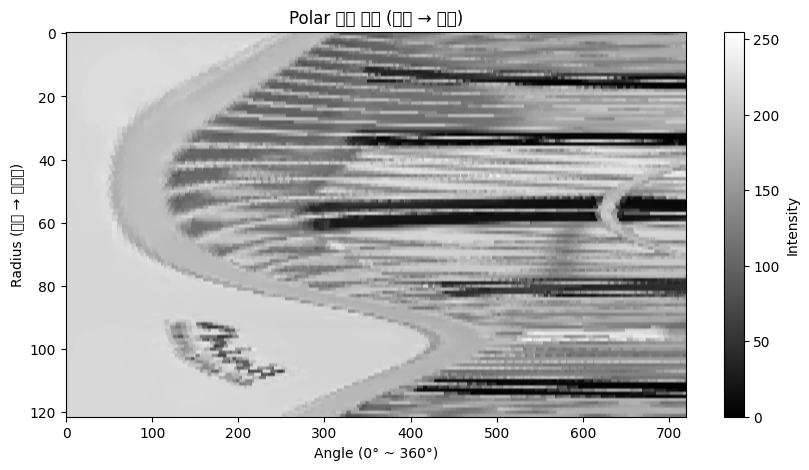

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ====== 입력 설정 ======
video_path = "fan_spin.mp4"   # 영어 이름 버전으로 저장한 영상 경로
x, y, w, h = 245, 62, 245, 325  # ROI (팬 영역)
polar_w = 720                   # 각도 해상도 (360°)
polar_h = int(min(w, h) / 2)    # 반지름 해상도

# ====== 영상 읽기 ======
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

if not ret or frame is None:
    raise ValueError("❌ 영상을 읽을 수 없습니다. 경로를 확인하세요.")

# ====== ROI 잘라내기 ======
frame = cv2.resize(frame, (640, 480))
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
roi = gray[y:y+h, x:x+w]

# ====== 중심점 및 반경 ======
cx, cy = w // 2, h // 2
radius = min(w, h) // 2 - 5

# ====== Polar 변환 ======
polar = cv2.warpPolar(roi, (polar_w, polar_h), (cx, cy), radius, cv2.WARP_POLAR_LINEAR)

# ====== 시각화 ======
plt.figure(figsize=(10,5))
plt.imshow(polar, cmap='gray', aspect='auto')
plt.title("Polar 변환 결과 (원형 → 선형)")
plt.xlabel("Angle (0° ~ 360°)")
plt.ylabel("Radius (중심 → 바깥쪽)")
plt.colorbar(label="Intensity")
plt.savefig("polar_speed_plot.png", dpi=200)
plt.show()



FPS = 30.0
🎥 저장 완료: rotation_fm.mp4


/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/654473434.py:166: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.


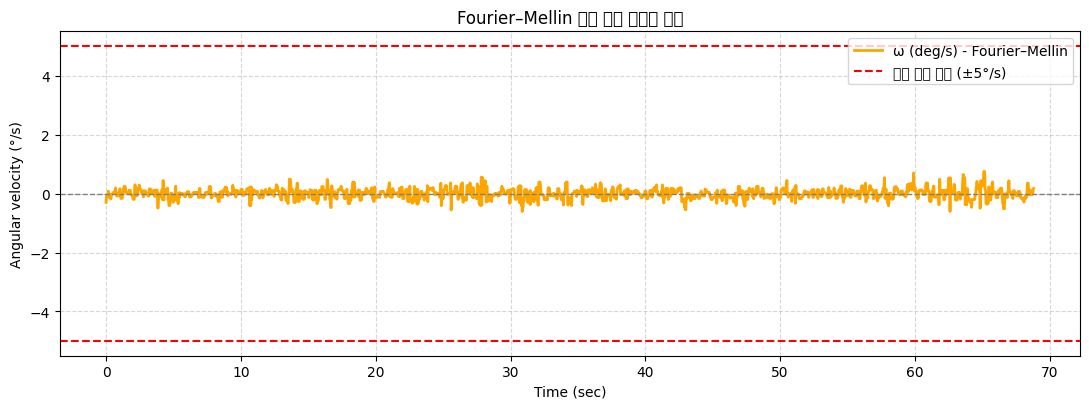

✅ rotation_fm.csv / rotation_fm_plot.png 생성 완료


In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# ========= 사용자 설정 =========
video_path = "fan_spin.mp4"      # 영어 파일명 권장 (경로 문제 방지)
x, y, w, h = 245, 62, 245, 325    # ROI (resize(640,480) 기준)
resize_wh = (640, 480)

# 로그-폴라 해상도(각도축 너비 = 각도 분해능, 반경축 높이 = 주파수 반경 샘플 수)
LP_W = 720                         # 360° 대응 → 0.5°/px
LP_H = min(w, h)//2                # 반경 방향 샘플 수

# 시각화/판정 파라미터
STOP_THRESH = 5.0                  # |ω| < 5°/s → STOP 표기
MEDFILT_K = 5                      # 그래프 median filter 커널 (홀수)

# ========= 유틸 함수 =========
def to_gray_resized(frame, size):
    f = cv2.resize(frame, size)
    g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
    return g

def build_circular_mask(h, w, margin=5):
    cx, cy = w//2, h//2
    r = min(w, h)//2 - margin
    mask = np.zeros((h, w), np.uint8)
    cv2.circle(mask, (cx, cy), r, 255, -1)
    return mask, (cx, cy), r

def fft_logpolar_mag(img, mask, center, radius):
    """
    1) 원판 영역 마스킹 + 해닝창으로 경계 완화
    2) 2D FFT → magnitude spectrum
    3) log(1+mag) 후 로그-폴라 변환
    4) 정규화 반환 (float32)
    """
    roi = cv2.bitwise_and(img, img, mask=mask)
    # 해닝창(원판 내부만 1, 에지 스무딩)
    hann_y = cv2.createHanningWindow((roi.shape[1], roi.shape[0]), cv2.CV_32F)
    roi32 = roi.astype(np.float32) * hann_y

    # 2D FFT → magnitude
    dft = cv2.dft(roi32, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft, axes=(0,1))
    real, imag = cv2.split(dft_shift)
    mag = cv2.magnitude(real, imag)

    # 로그 스케일
    mag = np.log1p(mag)

    # 로그-폴라 (회전/스케일 → 평행이동)
    flags = cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS
    lp = cv2.warpPolar(mag, (LP_W, LP_H), center, radius, flags)

    # 정규화
    lp = cv2.normalize(lp, None, 0, 1, cv2.NORM_MINMAX).astype(np.float32)
    return lp

def phase_shift_dx(lp_prev, lp_curr):
    """
    로그-폴라 magnitude 스펙트럼 사이의 평행이동 추정.
    x축 이동(dx) = 회전 각도의 변화(샘플 단위), y축 이동(dy) = 스케일(배율) 변화.
    """
    # 조명/노이즈 완화
    prev_f = cv2.GaussianBlur(lp_prev, (5,5), 0)
    curr_f = cv2.GaussianBlur(lp_curr, (5,5), 0)
    (shift, _) = cv2.phaseCorrelate(prev_f, curr_f)
    dx = shift[0]

    # 래핑 보정(주기=LP_W): 큰 음/양 이동을 최근접 등가값으로 접기
    if dx >  LP_W/2:  dx -= LP_W
    if dx < -LP_W/2:  dx += LP_W
    return dx

def median_filter(arr, k=5):
    if k < 3 or k % 2 == 0: return np.array(arr)
    pad = k//2
    arrp = np.pad(arr, (pad,pad), mode='edge')
    out = np.zeros_like(arr, dtype=np.float32)
    for i in range(len(arr)):
        out[i] = np.median(arrp[i:i+k])
    return out

# ========= 메인 =========
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"영상 오픈 실패: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or np.isnan(fps): fps = 30.0
print(f"FPS = {fps}")

# 첫 프레임 준비
ret, frame0 = cap.read()
if not ret: raise RuntimeError("첫 프레임 읽기 실패")
g0 = to_gray_resized(frame0, resize_wh)
roi0 = g0[y:y+h, x:x+w]
mask, center, radius = build_circular_mask(h, w, margin=5)

lp_prev = fft_logpolar_mag(roi0, mask, center, radius)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("rotation_fm.mp4", fourcc, fps, (w, h))

omegas = []   # deg/s
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret: break
    g = to_gray_resized(frame, resize_wh)
    # roi = g[y:y+h, x:x+w]
    # ROI를 절반만 사용 (왼쪽 or 오른쪽)
    roi = g[y:y+h, x:x+w//2]
    mask, center, radius = build_circular_mask(h, w//2, margin=5)

    
    lp_curr = fft_logpolar_mag(roi, mask, center, radius)
    dx = phase_shift_dx(lp_prev, lp_curr)

    # dx(샘플) → 각도 변화(deg/frame) → 각속도(deg/s)
    dtheta = dx * (360.0 / LP_W)
    omega = dtheta * fps
    omegas.append(omega)

    # 영상 오버레이
    disp = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
    txt = f"ω = {omega:+.1f}°/s"
    color = (0,255,0) if omega >= 0 else (0,0,255)
    cv2.putText(disp, txt, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    if abs(omega) < STOP_THRESH:
        cv2.putText(disp, "STOP (|ω|<5°/s)", (12, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
    out.write(disp)

    lp_prev = lp_curr
    frame_idx += 1

cap.release()
out.release()
print("🎥 저장 완료: rotation_fm.mp4")

# ========= 결과 저장/시각화 =========
# 스파이크 완화(옵션): median filter
omegas_f = median_filter(np.array(omegas, dtype=np.float32), k=MEDFILT_K)

# CSV
with open("rotation_fm.csv", "w", newline="") as f:
    wtr = csv.writer(f); wtr.writerow(["frame","time_sec","omega_deg_per_s"])
    for i, wv in enumerate(omegas_f):
        wtr.writerow([i, i/fps, float(wv)])

# Plot
t = np.arange(len(omegas_f)) / fps
plt.figure(figsize=(11,4.2))
plt.plot(t, omegas_f, color='orange', linewidth=2, label="ω (deg/s) - Fourier–Mellin")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(+STOP_THRESH, color='red', linestyle='--', label='정지 판정 경계 (±5°/s)')
plt.axhline(-STOP_THRESH, color='red', linestyle='--')
plt.xlabel("Time (sec)")
plt.ylabel("Angular velocity (°/s)")
plt.title("Fourier–Mellin 기반 회전 각속도 추정")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("rotation_fm_plot.png", dpi=200)
plt.show()

print("✅ rotation_fm.csv / rotation_fm_plot.png 생성 완료")


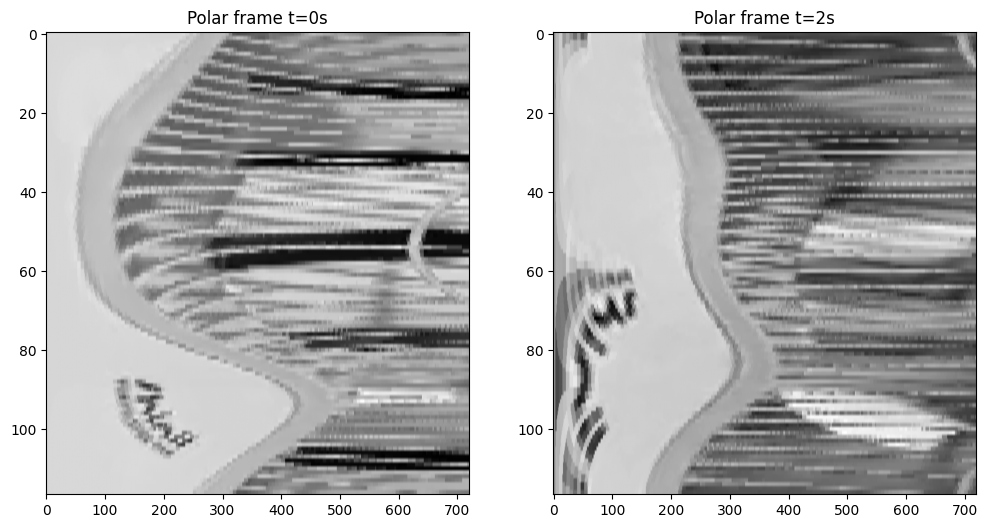

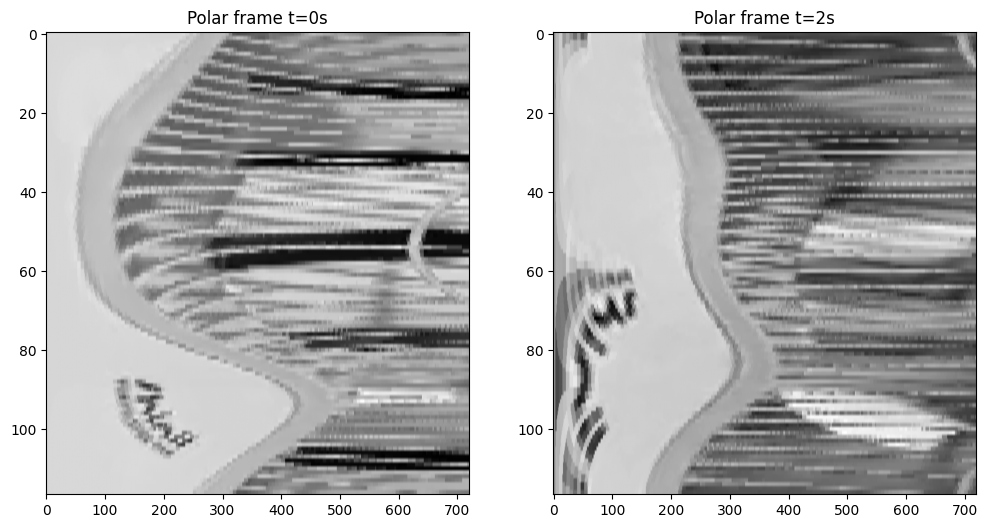

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

cap = cv2.VideoCapture("fan_spin.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
ret, f1 = cap.read()
for _ in range(int(fps*2)):  # 2초쯤 뒤 프레임으로 이동
    ret, f2 = cap.read()
cap.release()

f1 = cv2.resize(f1, (640,480))
f2 = cv2.resize(f2, (640,480))
g1, g2 = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in (f1,f2)]
roi1, roi2 = [g[y:y+h, x:x+w] for g in (g1,g2)]

cx, cy = w//2, h//2
radius = min(w,h)//2 - 5
polar1 = cv2.warpPolar(roi1, (720, radius), (cx,cy), radius, cv2.WARP_POLAR_LINEAR)
polar2 = cv2.warpPolar(roi2, (720, radius), (cx,cy), radius, cv2.WARP_POLAR_LINEAR)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(polar1, cmap='gray', aspect='auto')
plt.title("Polar frame t=0s")
plt.subplot(1,2,2)
plt.imshow(polar2, cmap='gray', aspect='auto')
plt.title("Polar frame t=2s")
plt.show()
import cv2
import matplotlib.pyplot as plt
import numpy as np

cap = cv2.VideoCapture("fan_spin.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
ret, f1 = cap.read()
for _ in range(int(fps*2)):  # 2초쯤 뒤 프레임으로 이동
    ret, f2 = cap.read()
cap.release()

f1 = cv2.resize(f1, (640,480))
f2 = cv2.resize(f2, (640,480))
g1, g2 = [cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in (f1,f2)]
roi1, roi2 = [g[y:y+h, x:x+w] for g in (g1,g2)]

cx, cy = w//2, h//2
radius = min(w,h)//2 - 5
polar1 = cv2.warpPolar(roi1, (720, radius), (cx,cy), radius, cv2.WARP_POLAR_LINEAR)
polar2 = cv2.warpPolar(roi2, (720, radius), (cx,cy), radius, cv2.WARP_POLAR_LINEAR)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(polar1, cmap='gray', aspect='auto')
plt.title("Polar frame t=0s")
plt.subplot(1,2,2)
plt.imshow(polar2, cmap='gray', aspect='auto')
plt.title("Polar frame t=2s")
plt.show()


🔍 중심 탐색 시작: ±15px 범위, 5px 간격
offset (-15,-15) → mean|ω|=0.381
offset (-15,-10) → mean|ω|=0.376
offset (-15,-5) → mean|ω|=0.369
offset (-15,0) → mean|ω|=0.338
offset (-15,5) → mean|ω|=0.369
offset (-15,10) → mean|ω|=0.396
offset (-15,15) → mean|ω|=0.402
offset (-10,-15) → mean|ω|=0.396
offset (-10,-10) → mean|ω|=0.395
offset (-10,-5) → mean|ω|=0.416
offset (-10,0) → mean|ω|=0.381
offset (-10,5) → mean|ω|=0.428
offset (-10,10) → mean|ω|=0.436
offset (-10,15) → mean|ω|=0.462
offset (-5,-15) → mean|ω|=0.558
offset (-5,-10) → mean|ω|=0.600
offset (-5,-5) → mean|ω|=0.464
offset (-5,0) → mean|ω|=0.408
offset (-5,5) → mean|ω|=0.490
offset (-5,10) → mean|ω|=0.508
offset (-5,15) → mean|ω|=0.583
offset (0,-15) → mean|ω|=0.550
offset (0,-10) → mean|ω|=0.490
offset (0,-5) → mean|ω|=0.404
offset (0,0) → mean|ω|=0.287
offset (0,5) → mean|ω|=0.424
offset (0,10) → mean|ω|=0.519
offset (0,15) → mean|ω|=0.581
offset (5,-15) → mean|ω|=0.618
offset (5,-10) → mean|ω|=0.554
offset (5,-5) → mean|ω|=0.502
offs

/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_831005/3564574899.py:163: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaV

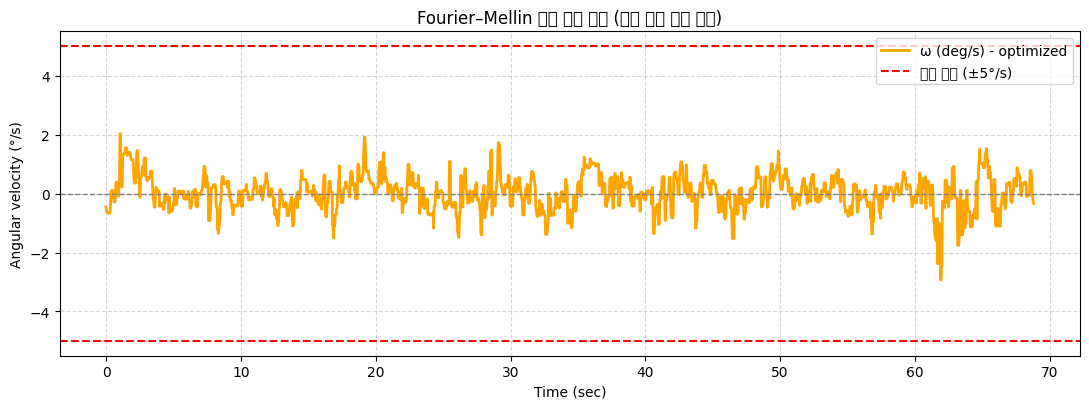

✅ rotation_fm_opt.csv / rotation_fm_opt_plot.png 생성 완료


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# ========= 사용자 설정 =========
video_path = "fan_spin.mp4"
x, y, w, h = 245, 62, 245, 325
resize_wh = (640, 480)
LP_W = 720
LP_H = min(w, h)//2
STOP_THRESH = 5.0
MEDFILT_K = 5
SEARCH_RANGE = 15  # 중심 오프셋 탐색 범위 (±px)
STEP = 5           # 오프셋 증가 간격(px)

# ========= 기본 유틸 =========
def to_gray_resized(frame, size):
    f = cv2.resize(frame, size)
    return cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)

def fft_logpolar_mag(img, mask, center, radius):
    roi = cv2.bitwise_and(img, img, mask=mask)
    hann_y = cv2.createHanningWindow((roi.shape[1], roi.shape[0]), cv2.CV_32F)
    roi32 = roi.astype(np.float32) * hann_y
    dft = cv2.dft(roi32, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft, axes=(0,1))
    real, imag = cv2.split(dft_shift)
    mag = cv2.magnitude(real, imag)
    mag = np.log1p(mag)
    flags = cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS
    lp = cv2.warpPolar(mag, (LP_W, LP_H), center, radius, flags)
    lp = cv2.normalize(lp, None, 0, 1, cv2.NORM_MINMAX).astype(np.float32)
    return lp

def phase_shift_dx(lp_prev, lp_curr):
    prev_f = cv2.GaussianBlur(lp_prev, (5,5), 0)
    curr_f = cv2.GaussianBlur(lp_curr, (5,5), 0)
    (shift, _) = cv2.phaseCorrelate(prev_f, curr_f)
    dx = shift[0]
    if dx >  LP_W/2: dx -= LP_W
    if dx < -LP_W/2: dx += LP_W
    return dx

def median_filter(arr, k=5):
    if k < 3 or k % 2 == 0: return np.array(arr)
    pad = k//2
    arrp = np.pad(arr, (pad,pad), mode='edge')
    out = np.zeros_like(arr, dtype=np.float32)
    for i in range(len(arr)):
        out[i] = np.median(arrp[i:i+k])
    return out

# ========= 중심 탐색 함수 =========
def optimize_center(video_path, x, y, w, h, resize_wh, search_range=15, step=5):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or np.isnan(fps): fps = 30
    ret, frame0 = cap.read()
    cap.release()
    g0 = to_gray_resized(frame0, resize_wh)
    roi0 = g0[y:y+h, x:x+w]

    base_cx, base_cy = w//2, h//2
    radius = min(w,h)//2 - 5
    best_mean, best_offset = 0, (0,0)

    print(f"🔍 중심 탐색 시작: ±{search_range}px 범위, {step}px 간격")

    for dx in range(-search_range, search_range+1, step):
        for dy in range(-search_range, search_range+1, step):
            cx, cy = base_cx + dx, base_cy + dy
            mask = np.zeros((h,w), np.uint8)
            cv2.circle(mask, (cx,cy), radius, 255, -1)

            lp_prev = fft_logpolar_mag(roi0, mask, (cx,cy), radius)
            omegas_tmp = []
            cap = cv2.VideoCapture(video_path)
            while True:
                ret, frame = cap.read()
                if not ret: break
                g = to_gray_resized(frame, resize_wh)
                roi = g[y:y+h, x:x+w]
                lp_curr = fft_logpolar_mag(roi, mask, (cx,cy), radius)
                dxs = phase_shift_dx(lp_prev, lp_curr)
                dtheta = dxs * (360.0 / LP_W)
                omega = dtheta * fps
                omegas_tmp.append(omega)
                lp_prev = lp_curr
            cap.release()

            mean_abs = np.mean(np.abs(omegas_tmp))
            print(f"offset ({dx},{dy}) → mean|ω|={mean_abs:.3f}")
            if mean_abs > best_mean:
                best_mean, best_offset = mean_abs, (dx,dy)

    print(f"✅ 최적 중심 offset: {best_offset} (mean|ω|={best_mean:.3f})")
    return best_offset

# ========= Fourier–Mellin 메인 =========
def run_fourier_mellin(video_path, x, y, w, h, resize_wh, center_offset=(0,0)):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps == 0 or np.isnan(fps): fps = 30
    print(f"🎥 FPS={fps}")

    ret, frame0 = cap.read()
    if not ret: raise RuntimeError("첫 프레임 읽기 실패")
    g0 = to_gray_resized(frame0, resize_wh)
    roi0 = g0[y:y+h, x:x+w]

    cx, cy = w//2 + center_offset[0], h//2 + center_offset[1]
    radius = min(w,h)//2 - 5
    mask = np.zeros((h,w), np.uint8)
    cv2.circle(mask, (cx,cy), radius, 255, -1)
    lp_prev = fft_logpolar_mag(roi0, mask, (cx,cy), radius)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter("rotation_fm_opt.mp4", fourcc, fps, (w, h))
    omegas = []

    while True:
        ret, frame = cap.read()
        if not ret: break
        g = to_gray_resized(frame, resize_wh)
        roi = g[y:y+h, x:x+w]
        lp_curr = fft_logpolar_mag(roi, mask, (cx,cy), radius)
        dx = phase_shift_dx(lp_prev, lp_curr)
        dtheta = dx * (360.0 / LP_W)
        omega = dtheta * fps
        omegas.append(omega)

        disp = cv2.cvtColor(roi, cv2.COLOR_GRAY2BGR)
        txt = f"ω = {omega:+.1f}°/s"
        color = (0,255,0) if omega >= 0 else (0,0,255)
        cv2.putText(disp, txt, (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        if abs(omega) < STOP_THRESH:
            cv2.putText(disp, "STOP (|ω|<5°/s)", (12, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
        out.write(disp)
        lp_prev = lp_curr

    cap.release()
    out.release()
    print("🎬 결과 저장: rotation_fm_opt.mp4")

    omegas_f = median_filter(np.array(omegas, dtype=np.float32), k=MEDFILT_K)
    with open("rotation_fm_opt.csv", "w", newline="") as f:
        wtr = csv.writer(f); wtr.writerow(["frame","time_sec","omega_deg_per_s"])
        for i, wv in enumerate(omegas_f):
            wtr.writerow([i, i/fps, float(wv)])

    t = np.arange(len(omegas_f)) / fps
    plt.figure(figsize=(11,4.2))
    plt.plot(t, omegas_f, color='orange', linewidth=2, label="ω (deg/s) - optimized")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(+STOP_THRESH, color='red', linestyle='--', label='정지 판정 (±5°/s)')
    plt.axhline(-STOP_THRESH, color='red', linestyle='--')
    plt.xlabel("Time (sec)")
    plt.ylabel("Angular velocity (°/s)")
    plt.title("Fourier–Mellin 기반 회전 추정 (자동 중심 보정 적용)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("rotation_fm_opt_plot.png", dpi=200)
    plt.show()
    print("✅ rotation_fm_opt.csv / rotation_fm_opt_plot.png 생성 완료")

# ========= 실행 =========
offset = optimize_center(video_path, x, y, w, h, resize_wh, search_range=SEARCH_RANGE, step=STEP)
run_fourier_mellin(video_path, x, y, w, h, resize_wh, center_offset=offset)
